# **Imports**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# **Loading the Data**

In [ ]:
df = pd.read_csv('dataset.csv', parse_dates=['Timestamp'])

# **Exploratory Data Analysis**

In [ ]:
df.head()

,Timestamp,String,Irradiance,Module_Temp,Ambient_Temp,Voltage,Current,Fault_Type
0,2025-01-01 10:33:00+05:30,String-1,760.787744,38.243446,34.654552,28.984000,9.525357,Normal
1,2025-01-01 13:15:00+05:30,String-1,956.515028,34.679934,29.085086,28.249070,11.916491,Normal
2,2025-01-01 16:44:00+05:30,String-1,859.186270,35.654215,31.332074,28.620821,10.731708,Normal
3,2025-01-01 18:38:00+05:30,String-2,965.671564,53.060418,36.606689,28.213616,12.027486,Normal
4,2025-01-01 06:07:00+05:30,String-1,618.768636,38.862544,33.687548,0.000000,12.442858,Short_Circuit


In [ ]:
df.tail()

,Timestamp,String,Irradiance,Module_Temp,Ambient_Temp,Voltage,Current,Fault_Type
2995,2025-01-01 10:45:00+05:30,String-1,685.166574,36.920355,28.089337,29.250889,8.592989,Normal
2996,2025-01-01 08:52:00+05:30,String-2,1000.000000,43.031923,28.604487,28.080105,12.442858,Normal
2997,2025-01-01 17:29:00+05:30,String-1,538.169135,31.128969,26.896630,29.723826,6.769000,Normal
2998,2025-01-01 22:00:00+05:30,String-1,869.142434,30.915886,25.299568,28.583284,10.853307,Normal
2999,2025-01-01 10:59:00+05:30,String-1,755.455005,36.551914,31.047256,29.003215,9.459752,Normal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                    
---  ------        --------------  -----                    
 0   Timestamp     3000 non-null   datetime64[ns, UTC+05:30]
 1   String        3000 non-null   object                   
 2   Irradiance    3000 non-null   float64                  
 3   Module_Temp   3000 non-null   float64                  
 4   Ambient_Temp  3000 non-null   float64                  
 5   Voltage       3000 non-null   float64                  
 6   Current       3000 non-null   float64                  
 7   Fault_Type    3000 non-null   object                   
dtypes: datetime64[ns, UTC+05:30](1), float64(5), object(2)
memory usage: 187.6+ KB


In [ ]:
df.describe()

,Irradiance,Module_Temp,Ambient_Temp,Voltage,Current
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,787.801010,36.703995,29.872898,27.496915,8.864266
std,177.115680,6.973822,4.846198,6.410831,3.253598
min,181.437087,20.705231,15.508048,0.000000,0.000000
25%,665.141039,31.816194,26.556769,28.172034,7.069049
50%,803.244014,36.086177,29.735806,28.884928,9.459752
75%,944.981521,40.563986,33.385364,29.498563,11.647694
max,1000.000000,77.499674,45.000000,30.257315,12.442858


In [ ]:
df['Fault_Type'].value_counts()

,count
Fault_Type,
Normal,2152
Shading,275
Hotspot,268
Short_Circuit,153
Open_Circuit,152


<Axes: xlabel='Timestamp', ylabel='Irradiance'>

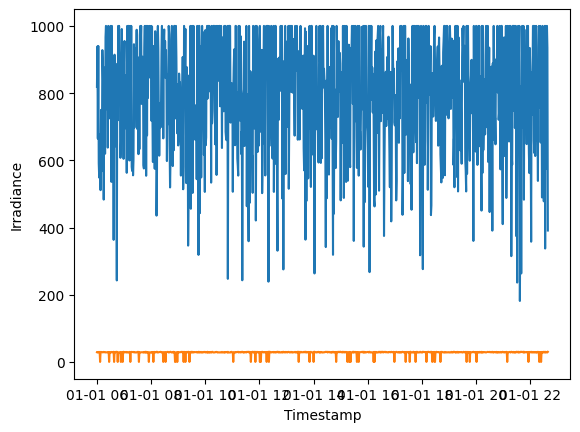

In [ ]:
sns.lineplot(data=df[df['String'] == 'String-1'], x='Timestamp', y='Irradiance')
sns.lineplot(data=df[df['String'] == 'String-1'], x='Timestamp', y='Voltage')

In [ ]:
fig = px.box(x='Fault_Type', y='Voltage', data_frame=df)
fig.show()

In [ ]:
fig = px.box(x='Fault_Type', y='Irradiance', data_frame=df)
fig.show()

In [ ]:
fig = px.box(x='Fault_Type', y='Ambient_Temp', data_frame=df)
fig.show()

In [ ]:
fig = px.box(x='Fault_Type', y='Module_Temp', data_frame=df)
fig.show()

In [ ]:
fig = px.box(x='String', y='Irradiance', data_frame=df, color='Fault_Type')
fig.show()

In [ ]:
fig = px.box(x='String', y='Module_Temp', data_frame=df, color='Fault_Type')
fig.show()

In [ ]:
fig = px.box(x='String', y='Ambient_Temp', data_frame=df, color='Fault_Type')
fig.show()

In [ ]:
fig = px.box(x='String', y='Current', data_frame=df, color='Fault_Type')
fig.show()

In [ ]:
fig = px.box(x='String', y='Voltage', data_frame=df, color='Fault_Type')
fig.show()

# **Distribution Analysis**

In [ ]:
fig = px.histogram(
    df,
    x='Voltage',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Voltage Distribution by Fault Type'
)
fig.show()

In [ ]:
fig = px.histogram(
    df,
    x='Current',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Current Distribution by Fault Type'
)
fig.show()

In [ ]:
fig = px.histogram(
    df,
    x='Module_Temp',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Module Temperature Distribution by Fault Type'
)
fig.show()

In [ ]:
fig = px.histogram(
    df,
    x='Ambient_Temp',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Module Temperature Distribution by Fault Type'
)
fig.show()

# **Scatterplots**

In [ ]:
fig = px.scatter(
    df,
    x='Voltage',
    y='Current',
    color='Fault_Type',
    title='Current vs Voltage',
    hover_data=['Irradiance', 'Module_Temp', 'Ambient_Temp']
)
fig.show()

# **Power Analysis**

In [ ]:
df['Power'] = df['Voltage'] * df['Current']

fig = px.histogram(
    df,
    x='Power',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Power Distribution by Fault Type'
)
fig.show()

In [ ]:
numeric_cols = ['Voltage', 'Current', 'Irradiance', 'Module_Temp', 'Ambient_Temp']
df_resampled = (
    df.set_index('Timestamp')
      .groupby('String')[numeric_cols]
      .resample('1H')
      .mean()
      .reset_index()
)
fig = px.line(
    df_resampled,
    x='Timestamp',
    y='Voltage',
    color='String',
    title='Hourly Average Voltage per String'
)
fig.show()

/tmp/ipython-input-390489246.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



# **Correlation Analysis**

In [ ]:
corr = df[['Voltage', 'Current', 'Irradiance', 'Module_Temp', 'Ambient_Temp']].corr()

# Plot heatmap
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    origin='upper',
    aspect='auto',
    labels=dict(color="Correlation"),
    title='Correlation Heatmap of PV Features'
)
fig.show()